In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *

In [2]:
def neighbor_maps_square(lattice: SquareLattice):
    X, Y = lattice.X, lattice.Y
    N = lattice.num_sites

    nbr = {"+x": -cp.ones(N, dtype=int),
           "-x": -cp.ones(N, dtype=int),
           "+y": -cp.ones(N, dtype=int),
           "-y": -cp.ones(N, dtype=int)}

    for y in range(Y):
        for x in range(X):
            i = y * X + x
            # +x
            if x < X:
                nbr["+x"][i] = i + 1
            elif lattice.pbc_x and X > 2:
                nbr["+x"][i] = y * X

            # -x
            if x > 0:
                nbr["-x"][i] = i - 1
            elif lattice.pbc_x and X > 2:
                nbr["-x"][i] = y * X + (X-1)

            # +y
            if y < Y:
                nbr["+y"][i] = (y+1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["+y"][i] = x

            # -y
            if y > 0:
                nbr["-y"][i] = (y-1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["-y"][i] = (Y-1) * X + x

    return nbr


In [3]:
def gather_at(j_idx, arr):
    # arr is (Neig,N). Return (Neig,N) with invalid neighbors zeroed.
    valid = (j_idx >= 0)
    j_safe = cp.where(valid, j_idx, 0)
    out = arr[:, j_safe]
    return out * valid[cp.newaxis, :]  # zero invalid sites

def correlators(H, T):

    nbr = neighbor_maps_square(H.lattice)
    F0 = cp.zeros_like(H.gap)
    F = {}          # singlet-like (up at i, down at j)
    Fuu = {}        # triplet component uu
    Fdd = {}        # triplet component dd


    eigval, eigvec = H.diagonalize(drop_matrix=False)
    eigvec = eigvec[:, eigval >= 0]
    eigval = eigval[eigval >= 0]
    eigvec = eigvec.T.reshape((eigval.size, -1, 4))

    f = fermi_dirac(eigval, T)          # (Neig,)
    u_up = eigvec[:, :, 0]              # (Neig, Nsites)
    u_dn = eigvec[:, :, 1]
    v_up = eigvec[:, :, 2]
    v_dn = eigvec[:, :, 3]

    F0 = (
        cp.einsum('ni,ni,n->i', u_dn, cp.conj(v_up), f) +
        cp.einsum('ni,ni,n->i', u_up, cp.conj(v_dn), (1-f))
    )
    
    for d in ["+x", "-x", "+y", "-y"]:
        j = nbr[d]

        vdn_j = gather_at(j, v_dn)
        udn_j = gather_at(j, u_dn)
        vup_j = gather_at(j, v_up)
        uup_j = gather_at(j, u_up)

        # Eqn 1: F_{i,↑↓}^d
        F[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(udn_j), f)
        )
        # Eqn 2: F_{i,↑↑}^d
        Fuu[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vup_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(uup_j), f)
        )
        # Eqn 3: F_{i,↓↓}^d
        Fdd[d] = (
            cp.einsum('ni,ni,n->i', u_dn, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_dn, cp.conj(udn_j), f)
        )
    return F0, F, Fuu, Fdd

In [4]:
def correlators(H, T):
    N = H.lattice.num_sites
    F0 = cp.zeros_like(H.gap)
    F = cp.zeros((N,N), dtype=cp.complex128)
    Fuu = cp.zeros((N,N), dtype=cp.complex128)
    Fdd = cp.zeros((N,N), dtype=cp.complex128)

    eigval, eigvec = H.diagonalize(drop_matrix=False)
    eigvec = eigvec[:, eigval >= 0]
    eigval = eigval[eigval >= 0]
    eigvec = eigvec.T.reshape((eigval.size, -1, 4))

    f = fermi_dirac(eigval, T)          # (Neig,)
    u_up = eigvec[:, :, 0] #u             # (Neig, Nsites)
    u_dn = eigvec[:, :, 1] #v
    v_up = eigvec[:, :, 2] #w
    v_dn = eigvec[:, :, 3] #x

    F0 = (
        cp.einsum('ni,ni,n->i', u_dn, cp.conj(v_up), f) +
        cp.einsum('ni,ni,n->i', u_up, cp.conj(v_dn), (1-f))
    )
    
    for i,j in H.lattice.edges:

        # Eqn 1: F_{ij,↑↓}^d
        F[i][j] = (
            cp.einsum('n,n,n->', u_up[:,i], cp.conj(v_dn[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,i]), u_dn[:,j], f)
        )        
        # Eqn 1: F_{ji,↑↓}^d
        F[j][i] = (
            cp.einsum('n,n,n->', u_up[:,j], cp.conj(v_dn[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,j]), u_dn[:,i], f)
        )
        # Eqn 2: F_{ij,↑↑}^d
        Fuu[i][j] = (
            cp.einsum('n,n,n->', u_up[:,i], cp.conj(v_up[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,i]), u_up[:,j], f)
        )
        # Eqn 2: F_{ji,↑↑}^d
        Fuu[j][i] = (
            cp.einsum('n,n,n->', u_up[:,j], cp.conj(v_up[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,j]), u_up[:,i], f)
        )
        # Eqn 3: F_{ij,↓↓}^d
        Fdd[i][j] = (
            cp.einsum('n,n,n->', u_dn[:,i], cp.conj(v_dn[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_dn[:,j]), u_dn[:,i], f)
        )
        # Eqn 3: F_{ji,↓↓}^d
        Fdd[j][i] = (
            cp.einsum('n,n,n->', u_dn[:,j], cp.conj(v_dn[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_dn[:,i]), u_dn[:,j], f)
        )
    return F0, F, Fuu, Fdd

In [5]:
def arr_converged(new, old, atol, rtol, nonzero_threshold=1e-6):
    abs = cp.linalg.norm(new - old) < atol 
    rel = cp.linalg.norm((new-old)/(new+1e-6)) < rtol or cp.linalg.norm(new) < 1e-6
    return abs and rel

In [6]:
from xxlimited import new


def bdg_self_consistency(H, U, V, V_prime, 
                         T, max_iter=100,
                         atol=1e-6, rtol=1e-4,
                         with_corr = False,
                         mix = 1.0, verbose=False):
        flag = False
        num_sites = H.lattice.num_sites
        F0 = cp.zeros_like(H.gap)
        F = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        Fuu = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        Fdd = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        for iteration in range(max_iter):
            F0_new, F_new, Fuu_new, Fdd_new = correlators(H, T)
            F0_new = mix * F0_new + (1-mix) * F0
            F_new = mix * F_new + (1-mix) * F
            Fuu_new = mix * Fuu_new + (1-mix) * Fuu
            Fdd_new = mix * Fdd_new + (1-mix) * Fdd

            for i in range(num_sites):
                # indices for the 4x4 block of site i
                sl = slice(4*i, 4*(i+1))
                H.matrix[sl, sl][:2, 2:] = 1j * U * F0_new[i] * s2
                H.matrix[sl, sl][2:, :2] = (1j * U * F0_new[i] * s2).conj().T

            for i, j in H.lattice.edges:
                sli = slice(4*i, 4*(i+1))
                slj = slice(4*j, 4*(j+1))

                H.matrix[sli, slj][0,3] = V * F_new[i][j]
                H.matrix[sli, slj][1,2] = -V * F_new[j][i]
                H.matrix[sli, slj][2,1] = -(V * F_new[i][j]).conj().T
                H.matrix[sli, slj][3,0] = (V * F_new[j][i]).conj().T

                H.matrix[slj, sli][0,2] = -V_prime * Fuu_new[i][j]
                H.matrix[slj, sli][1,3] = -V_prime * Fdd_new[i][j]
                H.matrix[slj, sli][2,0] = (-V_prime * Fuu_new[j][i]).conj().T
                H.matrix[slj, sli][3,1] = (-V_prime * Fdd_new[j][i]).conj().T
            if verbose:
                print(f"Iteration {iteration+1}:\
                  \nAbs: {cp.linalg.norm(F_new - F)}\
                  \nRel: {cp.linalg.norm((F_new - F)/(F_new+1e-12))}\
                  \nIndex: {cp.argmax(cp.abs(F_new.flatten() - F.flatten()))}\
                  \nCorrelation: {F.flatten()[cp.argmax(cp.abs(F_new.flatten() - F.flatten()))]}\
                  \nCorr_new: {F_new.flatten()[cp.argmax(cp.abs(F_new.flatten() - F.flatten()))]}\
                  \nCorrelation_dd: {Fdd.flatten()[cp.argmax(cp.abs(Fdd_new.flatten() - Fdd.flatten()))]}\
                  \nCorr_dd_new: {Fdd_new.flatten()[cp.argmax(cp.abs(Fdd_new.flatten() - Fdd.flatten()))]}\
                  \nCorrelation_uu: {Fuu.flatten()[cp.argmax(cp.abs(Fuu_new.flatten() - Fuu.flatten()))]}\
                  \nCorr_uu_new: {Fuu_new.flatten()[cp.argmax(cp.abs(Fuu_new.flatten() - Fuu.flatten()))]}")

                F_abs = cp.linalg.norm(F_new - F) < atol 
                F_rel = cp.linalg.norm((F_new-F)/(F_new+1e-12)) < rtol or cp.linalg.norm(F_new) < 1e-12
                print(f"F bool: {arr_converged(F_new, F, atol, rtol)}")
                Fuu_abs = cp.linalg.norm(Fuu_new - Fuu)
                Fuu_rel = cp.linalg.norm((Fuu_new-Fuu)/(Fuu_new+1e-12)) < rtol or cp.linalg.norm(Fuu_new) < 1e-12
                print(f"Fuu bool: {arr_converged(Fuu_new, Fuu, atol, rtol)}")
                Fdd_abs = cp.linalg.norm(Fdd_new - Fdd)
                Fdd_rel = cp.linalg.norm((Fdd_new-Fdd)/(Fdd_new+1e-12)) < rtol or cp.linalg.norm(Fdd_new) < 1e-12
                print(f"Fdd bool: {arr_converged(Fdd_new, Fdd, atol, rtol)}")
                F0_abs = cp.linalg.norm(F0_new - F0)
                F0_rel = cp.linalg.norm((F0_new-F0)/F0_new) < rtol or cp.linalg.norm(F0_new) < 1e-12
                print(f"F0 bool: {arr_converged(F0_new, F0, atol, rtol)}")
            if (arr_converged(F0_new, F0, atol, rtol)
                and arr_converged(F_new, F, atol, rtol)
                and arr_converged(Fuu_new, Fuu, atol, rtol)
                and arr_converged(Fdd_new, Fdd, atol, rtol)):
                print(f"Converged after {iteration+1} iterations.")
                flag = True
                F0 = F0_new
                F = F_new   
                Fuu = Fuu_new
                Fdd = Fdd_new
                break
            F0 = F0_new
            F = F_new
            Fuu = Fuu_new
            Fdd = Fdd_new
            
        if not flag:
            print(f"Failed to converge after {iteration+1} iterations")
        if with_corr:
            return F0, F, Fuu, Fdd

In [7]:
# def bdg_self_consistency(H, U, V, V_prime, 
#                          T, max_iter=100,
#                          atol=1e-6, rtol=1e-4,
#                          with_corr = False):
#         flag = False
#         num_sites = H.lattice.num_sites
#         F0 = cp.ones(num_sites, dtype=cp.complex128) * 0.1
#         F = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}
#         Fuu = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}
#         Fdd = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}

#         for iteration in range(max_iter):
#             F0_new, F_new, Fuu_new, Fdd_new = correlators(H, T)
#             gap_0 = -U * F0_new

#             for i in range(num_sites):
#                 # indices for the 4x4 block of site i
#                 sl = slice(4*i, 4*(i+1))
#                 H.matrix[sl, sl][:2, 2:] = -1j * gap_0[i] * s2
#                 H.matrix[sl, sl][2:, :2] = (-1j * gap_0[i] * s2).conj().T

#             for i, j in H.lattice.edges:
#                 # F_xT = (F["+x"][i]-F["-x"][j])/2
#                 # F_yT = (F["+y"][i]-F["-y"][j])/2
#                 sli = slice(4*i, 4*(i+1))
#                 slj = slice(4*j, 4*(j+1))
#                 dir = H.lattice.get_dir(i, j)

#                 H.matrix[sli, slj][0,3] = V * F_new[dir][i]
#                 H.matrix[sli, slj][1,2] = V * F_new[dir][i]
#                 H.matrix[sli, slj][2,1] = (V * F_new[dir][i]).conj().T
#                 H.matrix[sli, slj][3,0] = (V * F_new[dir][i]).conj().T

#                 H.matrix[slj, sli][0,2] = V_prime * Fuu_new[dir][i]
#                 H.matrix[slj, sli][1,3] = V_prime * Fdd_new[dir][i]
#                 H.matrix[slj, sli][2,0] = (V_prime * Fuu_new[dir][i]).conj().T
#                 H.matrix[slj, sli][3,1] = (V_prime * Fdd_new[dir][i]).conj().T

#             if (cp.max(cp.abs(F0_new - F0)) < atol + rtol * cp.max(cp.abs(gap_0))
#                 and dict_converged(F_new, F, atol, rtol)
#                 and dict_converged(Fuu_new, Fuu, atol, rtol)
#                 and dict_converged(Fdd_new, Fdd, atol, rtol)
#                 ):
#                 print(f"Converged after {iteration+1} iterations.")
#                 flag = True
#                 F0 = F0_new
#                 F = F_new   
#                 Fuu = Fuu_new
#                 Fdd = Fdd_new
#                 break
#             F0 = F0_new
#             F = F_new
#             Fuu = Fuu_new
#             Fdd = Fdd_new
            
#         if not flag:
#             print(f"Failed to converge after {iteration+1} iterations")
#         if with_corr:
#             return F0, F, Fuu, Fdd

### Periodic X and Y

In [44]:
t = 1
mu = -1.6* t
gap_0 = 0.0 * t
gap_p= cp.array([0.05, 0.0j]) * t
gap_d = 0.0 *  t
Y,X = 25,25
U = 2 * t
V = 2.0 * t
lattice = Lattice(X, Y, pbc_x=True, pbc_y=True)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p=gap_p)#, gap_p_dd=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p=gap_p)#, gap_p_dd=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1


In [45]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-6, atol=1e-6))

True


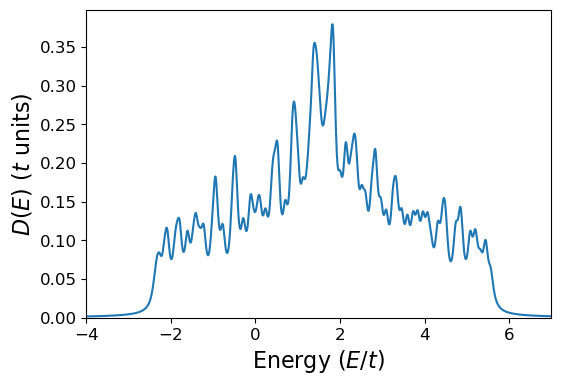

In [46]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.075, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [47]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=0,V=V,V_prime=0,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)

Iteration 1:                  
Abs: 1.2209930615632685                  
Rel: 35.3553391395896                  
Index: 40065                  
Correlation: 0j                  
Corr_new: (-0.034534898944524724+0j)                  
Correlation_dd: 0j                  
Corr_dd_new: (-2.592869495499084e-16+0j)                  
Correlation_uu: 0j                  
Corr_uu_new: (-2.8572793003139862e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True
Iteration 2:                  
Abs: 0.29001443002854893                  
Rel: 6.78590902571875                  
Index: 14397                  
Correlation: (0.03453489894452425+0j)                  
Corr_new: (0.0427377457491304+0j)                  
Correlation_dd: (-8.946023175721018e-17+0j)                  
Corr_dd_new: (2.318549405201306e-16+0j)                  
Correlation_uu: (-2.8572793003139862e-16+0j)                  
Corr_uu_new: (1.1602742014784131e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True

In [12]:
print(len(H.lattice.edges))
print(cp.count_nonzero(F))

2500
2500


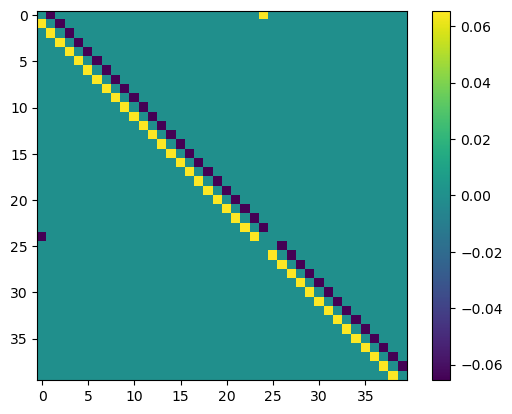

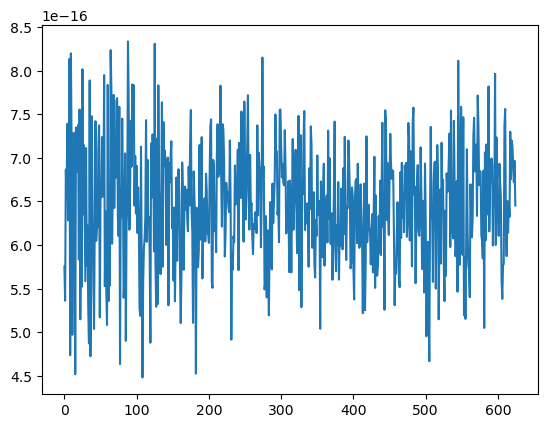

In [48]:
plt.figure()
plt.imshow(cp.asnumpy(cp.real(F))[0:40,0:40])
colorbar = plt.colorbar()

plt.figure()
plt.plot(cp.asnumpy(cp.real(F0)))


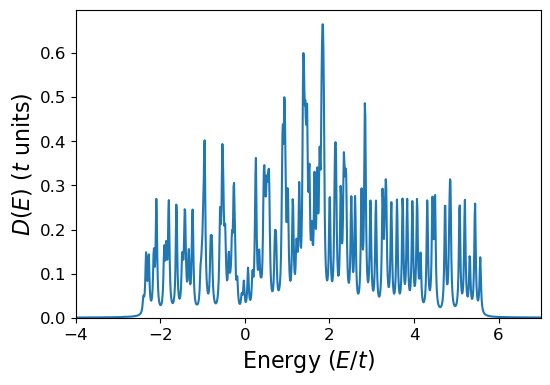

In [49]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [50]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-4, atol=1e-4))

True


Free energy: -1345.3039267666181
-0.06556426058039781
0.0
8.023374558081995e-16
3.440122260382596e-16


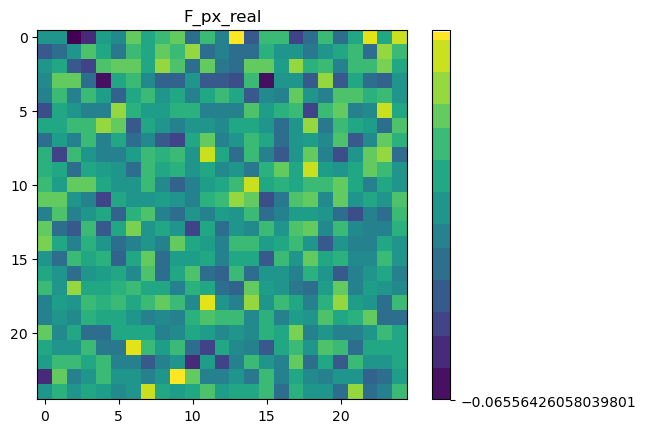

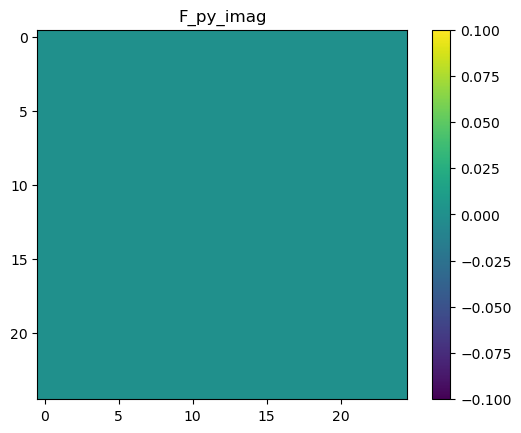

In [52]:
free_energy = H.free_energy(U=U, V=V, V_prime=0, temperature=0, drop_matrix=False)
print(f"Free energy: {free_energy}")
F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += F[i][j]
        elif dir == "-x":
            F_xminus[i] += F[i][j]
        elif dir == "+y":
            F_yplus[i] += F[i][j]
        elif dir == "-y":
            F_yminus[i] += F[i][j]
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((F_xplus-F_xminus)/2).reshape(25,25))), label="F_T_real")
plt.title("F_px_real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy((F_xplus-F_xminus)/2)))))
plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(25,25))), label="F_T_imag")
print(np.average((np.imag(cp.asnumpy((F_yplus-F_yminus)/2)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus+F_yplus+F_yminus)/4)))))

plt.title("F_py_imag")
plt.colorbar()

plt.show()
# -0.03712461549460403
# -0.03712461549460403
# Free energy: -1473.8140353133704

In [17]:
t = 1
mu = -2* t
gap_s = 0.0 * t
gap_p= cp.array([0.1, 0.1j]) * t / 2
gap_d = 0.1 *  t
Y,X = 25,25
U = 2 * t
V = 2.0 * t
lattice = Lattice(X, Y, pbc_x=True, pbc_y=True)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_s * s2
    block[2:, :2] = (-1j * gap_s * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p_dd=gap_p, gap_p_uu=gap_p)#, gap_p_dd=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p_dd=gap_p, gap_p_uu=gap_p)#, gap_p_uu=gap_p, gap_p_dd=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1


In [18]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=0,V=0,V_prime=V,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)

Iteration 1:                  
Abs: 3.9341167018393475e-15                  
Rel: 0.003934115564917922                  
Index: 20031                  
Correlation: 0j                  
Corr_new: (-3.004188694685772e-16-1.2479336411897607e-17j)                  
Correlation_dd: 0j                  
Corr_dd_new: (-0.02776715113224228-3.813681141717762e-17j)                  
Correlation_uu: 0j                  
Corr_uu_new: (-0.027767151132242325+1.9397054492123478e-17j)
F bool: True
Fuu bool: False
Fdd bool: False
F0 bool: True
Iteration 2:                  
Abs: 5.670013299444022e-15                  
Rel: 0.005670055465766441                  
Index: 7511                  
Correlation: (-2.2489487079254203e-16-1.3342462985149739e-17j)                  
Corr_new: (2.8786075899258495e-16-7.172463239112602e-17j)                  
Correlation_dd: (-0.02776715113224185-2.7592945289756088e-17j)                  
Corr_dd_new: (-0.030035648326956835+1.0293144375034258e-17j)                  

Free energy: -1483.3420277538896
0.037029365264134494
0.037029365264134494


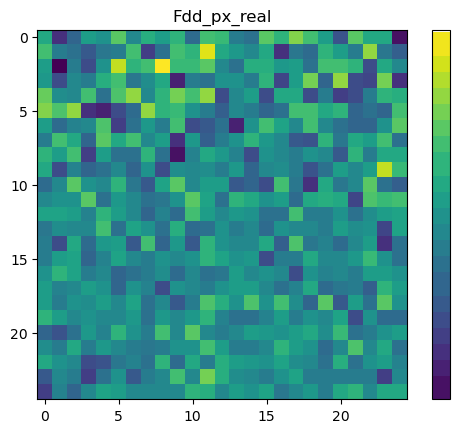

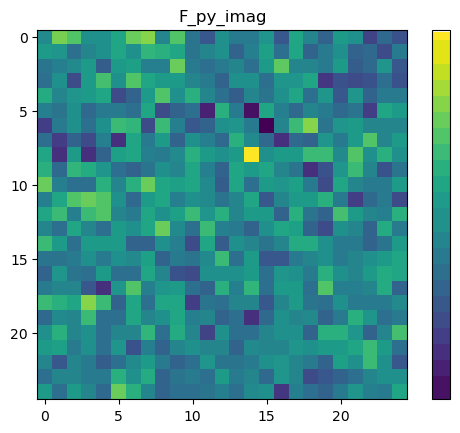

In [19]:
free_energy = H.free_energy(U=U, V=V, V_prime=V, temperature=0, drop_matrix=False)
print(f"Free energy: {free_energy}")

Fdd_S = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_T = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

Fdd_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        Fdd_S[i] += (Fdd[i][j]+Fdd[j][i])/2
        Fdd_T[i] += (Fdd[i][j]-Fdd[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            Fdd_xplus[i] += Fdd[i][j]
            # F_xminus.append(F[j][i].get())
        elif dir == "-x":
            Fdd_xminus[i] += Fdd[i][j]
            # F_xplus.append(F[j][i].get())
        elif dir == "+y":
            Fdd_yplus[i] += Fdd[i][j]
            # F_yminus.append(F[j][i].get())
        elif dir == "-y":
            Fdd_yminus[i] += Fdd[i][j]
            # F_yplus.append(F[j][i].get())
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((Fdd_xplus-Fdd_xminus)/2).reshape(25,25))), label="F_T_real")
plt.title("Fdd_px_real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy((Fdd_xplus-Fdd_xminus)/2)))))
plt.figure()
# plt.imshow(np.abs(np.imag(cp.asnumpy((F_T)).reshape(30,30))), label="F_T_imag")
# plt.imshow(np.abs(np.real(cp.asnumpy((F_xplus-F_xminus)/2).reshape(30,30))), label="F_T_imag")
plt.imshow((np.imag(cp.asnumpy((Fdd_yplus-Fdd_yminus)/2).reshape(25,25))), label="F_T_imag")
print(np.average((np.imag(cp.asnumpy((Fdd_yplus-Fdd_yminus)/2)))))

plt.title("F_py_imag")
plt.colorbar()

plt.show()
# -0.03712461549460403
# -0.03712461549460403
# Free energy: -1479.9185943869202
# -1483.3480425927253

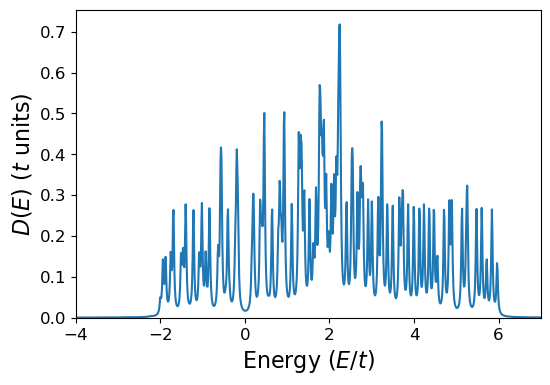

In [20]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

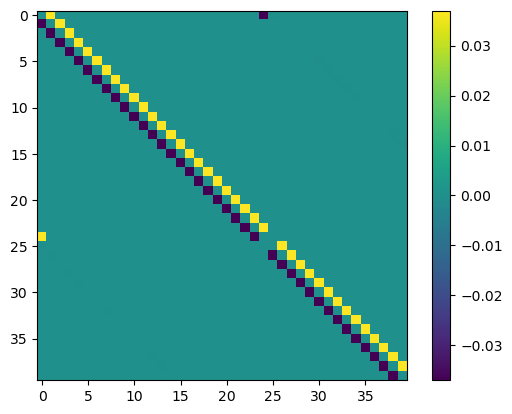

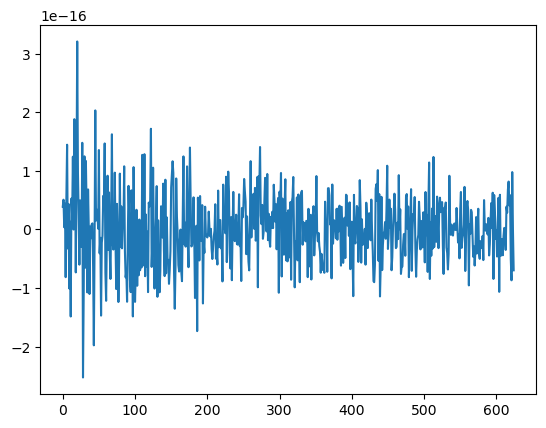

In [21]:
plt.figure()
plt.imshow(cp.asnumpy(cp.real(Fdd))[0:40,0:40])
colorbar = plt.colorbar()

plt.figure()
plt.plot(cp.asnumpy(cp.real(F0)))


In [22]:
disp = Fdd[25,0]
print(disp)
disp = Fdd[0,25]
print(disp)

(-3.396771525079195e-17-0.037029365264134514j)
(-6.279902270943383e-17+0.03702936526413457j)


In [23]:
print(np.average(np.imag(cp.asnumpy(Fdd_yplus))))
print(np.average(np.imag(cp.asnumpy(Fdd_yminus))))
print(np.average(np.imag(cp.asnumpy((Fdd_yplus-Fdd_yminus)/2))))

0.037029365264134494
-0.037029365264134494
0.037029365264134494


In [24]:
t = 1
mu = -2* t
gap_s = 0.0 * t
gap_p= cp.array([0., 0.j]) * t
gap_d = 0.1 *  t
Y,X = 25,25
U = 2 * t
V = 2.0 * t
lattice = Lattice(X, Y, pbc_x=True, pbc_y=True)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_s * s2
    block[2:, :2] = (-1j * gap_s * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_d = gap_d)#, gap_p_dd=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_d = gap_d)#, gap_p_uu=gap_p, gap_p_dd=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1


In [25]:
F0d, Fd, Fuud, Fddd = bdg_self_consistency(H,U=0,V=V,V_prime=0,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)
free_energy_d = H.free_energy(U=U, V=V, V_prime=V, temperature=0, drop_matrix=False)
print(f"Free energy: {free_energy_d}")

Iteration 1:                  
Abs: 1.8254744975658352                  
Rel: 50.0                  
Index: 24                  
Correlation: 0j                  
Corr_new: (0.03650948995131696+0j)                  
Correlation_dd: 0j                  
Corr_dd_new: (-2.644911199778388e-16+0j)                  
Correlation_uu: 0j                  
Corr_uu_new: (4.576718394168439e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True
Iteration 2:                  
Abs: 0.4156082085062982                  
Rel: 14.739277466643063                  
Index: 10015                  
Correlation: (0.036509489951316865+0j)                  
Corr_new: (0.02819732578119054+0j)                  
Correlation_dd: (-3.548051609458813e-17+0j)                  
Corr_dd_new: (2.6573795247619714e-16+0j)                  
Correlation_uu: (-4.2654546344653155e-16+0j)                  
Corr_uu_new: (1.3148661846817955e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True
Iteration 3:  

0.00023533768662102475
0.0


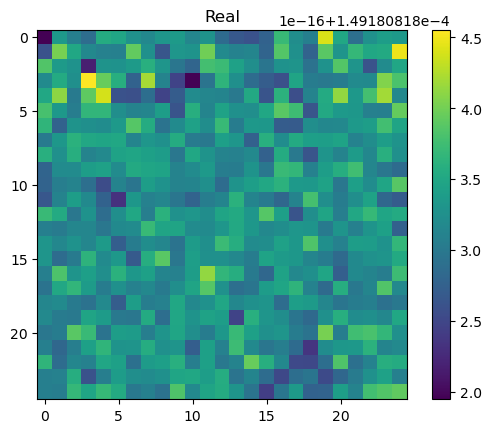

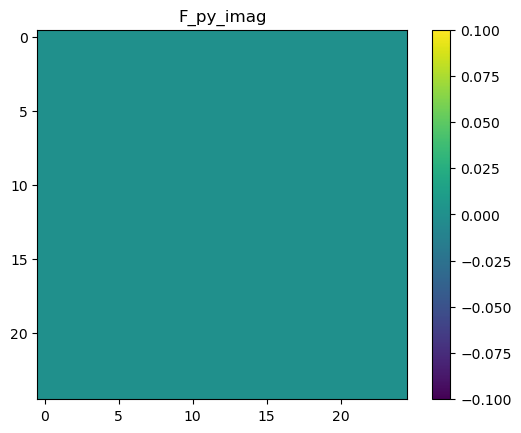

(-1.968872642779413e-09+0j)
(3.4694469519536144e-22+0j)


In [26]:
Fd_S = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fd_T = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

Fd_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fd_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fd_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fd_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        Fd_S[i] += (Fd[i][j]+Fd[j][i])/2
        Fd_T[i] += (Fd[i][j]-Fd[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            Fd_xplus[i] += Fd[i][j]
            # F_xminus.append(F[j][i].get())
        elif dir == "-x":
            Fd_xminus[i] += Fd[i][j]
            # F_xplus.append(F[j][i].get())
        elif dir == "+y":
            Fdd_yplus[i] += Fd[i][j]
            # F_yminus.append(F[j][i].get())
        elif dir == "-y":
            Fd_yminus[i] += Fd[i][j]
            # F_yplus.append(F[j][i].get())
    
F_dx2y2 = (Fd_xplus+Fd_xminus-Fd_yplus-Fd_yminus)/4
plt.figure()
plt.imshow(np.real(cp.asnumpy(F_dx2y2.reshape(25,25))), label="F_T_real")
plt.title("Real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy((Fd_xplus-Fd_xminus)/2)))))
plt.figure()
# plt.imshow(np.abs(np.imag(cp.asnumpy((F_T)).reshape(30,30))), label="F_T_imag")
# plt.imshow(np.abs(np.real(cp.asnumpy((F_xplus-F_xminus)/2).reshape(30,30))), label="F_T_imag")
plt.imshow(np.imag(cp.asnumpy(F_dx2y2.reshape(25,25))), label="F_T_imag")
print(np.average((np.imag(cp.asnumpy(F_dx2y2)/2))))

plt.title("F_py_imag")
plt.colorbar()
plt.show()

print(cp.average(Fd_S))
print(cp.average(Fd_T))

In [27]:
t = 1
mu = -2* t
gap_s = 0.0 * t
gap_p= cp.array([0.1, 0.1]) * t
gap_d = 0.1 *  t
Y,X = 25,25
U = 2 * t
V = 2.0 * t
lattice = Lattice(X, Y, pbc_x=True, pbc_y=True)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_s * s2
    block[2:, :2] = (-1j * gap_s * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p = gap_p)#, gap_p_dd=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p = gap_p)#, gap_p_uu=gap_p, gap_p_dd=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1


In [28]:
F0p, Fp, Fuup, Fddp = bdg_self_consistency(H,U=0,V=V,V_prime=0,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)
free_energy_p = H.free_energy(U=U, V=V, V_prime=V, temperature=0, drop_matrix=False)
print(f"Free energy: {free_energy_p}")

Iteration 1:                  
Abs: 2.149219483292514                  
Rel: 50.0                  
Index: 29423                  
Correlation: 0j                  
Corr_new: (-0.04298438966585055+0j)                  
Correlation_dd: 0j                  
Corr_dd_new: (2.368981746880827e-16+0j)                  
Correlation_uu: 0j                  
Corr_uu_new: (2.813098061785202e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True
Iteration 2:                  
Abs: 0.21051275917619722                  
Rel: 5.42920588652085                  
Index: 5033                  
Correlation: (-0.04298438966585043+0j)                  
Corr_new: (-0.03877413448232604+0j)                  
Correlation_dd: (1.6371452804531117e-16+0j)                  
Corr_dd_new: (-1.46543476138572e-16+0j)                  
Correlation_uu: (2.813098061785202e-16+0j)                  
Corr_uu_new: (-1.2400562347802957e-16+0j)
F bool: False
Fuu bool: True
Fdd bool: True
F0 bool: True
Iteration 3:   

-0.03042561711231782
-0.03042561711231773


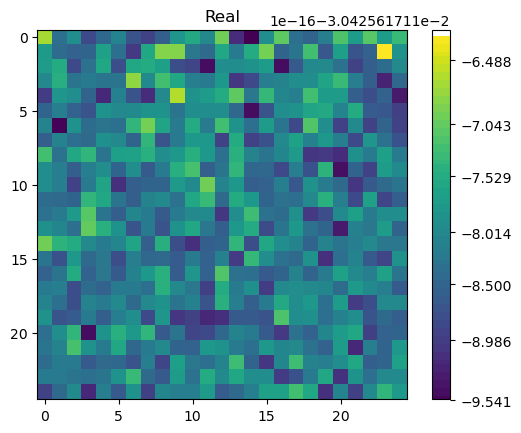

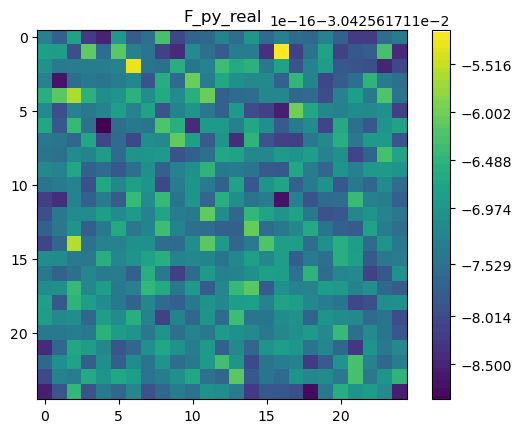

(-1.1718404024918528e-17+0j)
0j


In [29]:
Fp_S = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fp_T = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

Fp_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fp_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fp_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fp_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        Fp_S[i] += (Fp[i][j]+Fp[j][i])/2
        Fp_T[i] += (Fp[i][j]-Fp[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            Fp_xplus[i] += Fp[i][j]
            # F_xminus.append(F[j][i].get())
        elif dir == "-x":
            Fp_xminus[i] += Fp[i][j]
            # F_xplus.append(F[j][i].get())
        elif dir == "+y":
            Fp_yplus[i] += Fp[i][j]
            # F_yminus.append(F[j][i].get())
        elif dir == "-y":
            Fp_yminus[i] += Fp[i][j]
            # F_yplus.append(F[j][i].get())
    
F_px = (Fp_xplus-Fp_xminus)/2
F_py = (Fp_yplus-Fp_yminus)/2
plt.figure()
plt.imshow(np.real(cp.asnumpy(F_px.reshape(25,25))), label="F_px_real")
plt.title("Real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy(F_px)))))

plt.figure()
# plt.imshow(np.abs(np.imag(cp.asnumpy((F_T)).reshape(30,30))), label="F_T_imag")
# plt.imshow(np.abs(np.real(cp.asnumpy((F_xplus-F_xminus)/2).reshape(30,30))), label="F_T_imag")
plt.imshow(np.real(cp.asnumpy(F_py.reshape(25,25))), label="F_py_real")
print(np.average((np.real(cp.asnumpy(F_py)))))

plt.title("F_py_real")
plt.colorbar()
plt.show()

print(cp.average(Fp_S))
print(cp.average(Fp_T))